# <center>**INFO-6149 (26W) Machine Learning Security**</center>
## <center>**Project: Attack Detection and Defense**</ceneter>

## <center>**Professor: Bestan Maaroof**</center>
## <center>**Group: 05**</center>
### Group Member: 

###   1. Yun-Jiung Wang - 1256222 
###   2. Allyson Fuller - 0763664 
###   3. Gitanshu Gitanshu - 1352882 



#### Import Libs

In [18]:
import numpy as np
import copy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay

# SecML related
from secml.array import CArray
from secml.data import CDataset
from secml.ml.classifiers import CClassifierPyTorch
from secml.ml.peval.metrics import CMetricAccuracy

import time

### Check Device (CPU or GPU)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### Part 1:  Detecting Data Poisoning and Adversarial Attacks in Machine Learning 
#### Phase 1: Dataset Selection and Preprocessing 

##### Load the dataset

In [11]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

full_train_ds = datasets.GTSRB(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

full_test_ds = datasets.GTSRB(
    root="./data",
    split="test",
    transform=transform,
    download=True
)

#### Data Pre-Processing

In [12]:
# Stratified Split
def get_data(dataset, n_samples):
    labels = [s[1] for s in dataset._samples]
    indices = np.arange(len(dataset))
    # make sure every label could be trained
    idx, _ = train_test_split(indices, train_size=n_samples,shuffle=True, stratify=labels, random_state=42)
    return idx

train_idx = get_data(full_train_ds, 5000)
test_idx = get_data(full_test_ds, 1000)

# Create Subset
train_subset = Subset(full_train_ds, train_idx)
test_subset = Subset(full_test_ds, test_idx)

### Phase 2: Building a Machine Learning Model 

In [13]:
class GTSRB_CNN(nn.Module):
    def __init__(self):
        super(GTSRB_CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 43)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = GTSRB_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# change to SECML
clf = CClassifierPyTorch(model=model, loss=criterion, optimizer=optimizer, 
                         input_shape=(3, 32, 32), epochs=5, batch_size=32)

def subset_to_carray(subset):
    x_list, y_list = [], []
    for img, lbl in subset:
        x_list.append(img.numpy().flatten())
        y_list.append(lbl)
    return CArray(np.array(x_list)), CArray(np.array(y_list))

X_train, y_train = subset_to_carray(train_subset)
X_test, y_test = subset_to_carray(test_subset)

#### Train the Model

In [5]:
print("start training Baseline Model...")
clf.fit(X_train, y_train)

start training Baseline Model...


GTSRB_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)

#### Baseline Evaluation

In [6]:
y_pred = clf.predict(X_test)
metrix = CMetricAccuracy()
acc = metrix.performance_score(y_test, y_pred)
print(f"Baseline Accuracy: {acc:.4f}")

Baseline Accuracy: 0.7240


#### Confusion Matrix: Showing top 5 best and worst 5 classes

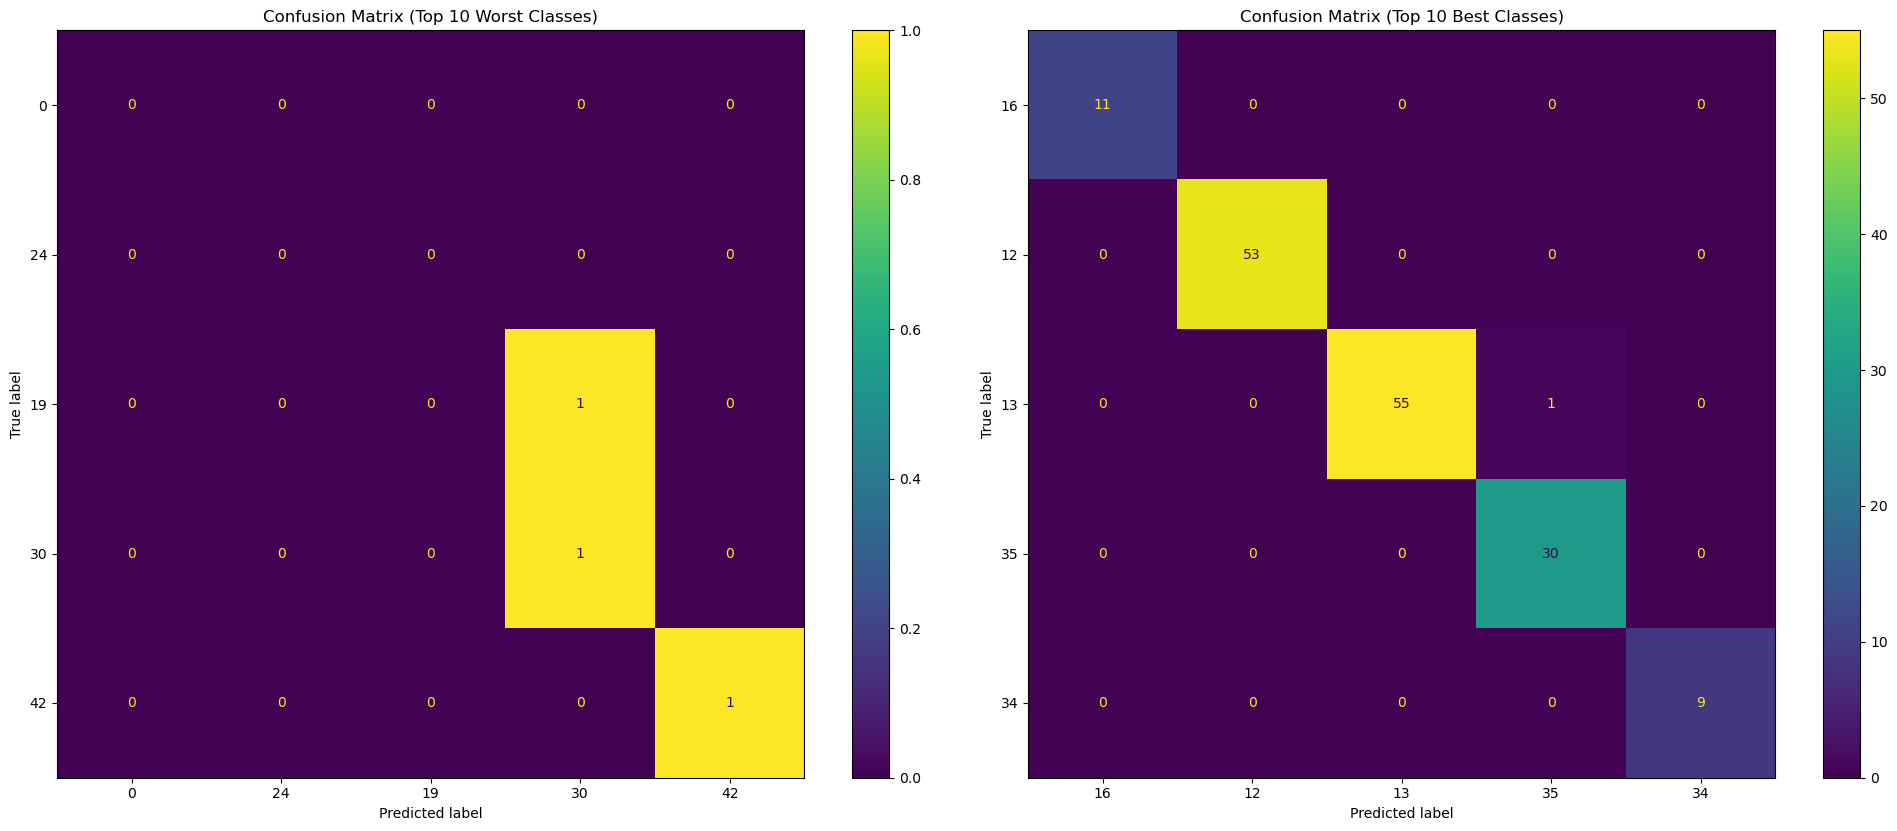

In [7]:
# Convert CArray to numpy to draw the confusion matrix
y_test_np = y_test.tondarray()
y_pred_np = y_pred.tondarray()

# Confusion Matrix
confs = confusion_matrix(y_test_np, y_pred_np)

#Graph
per_class_acc = confs.diagonal() / confs.sum(axis=1)


worst_idx = np.argsort(per_class_acc)[:5]   # Top 5 classes
best_idx = np.argsort(per_class_acc)[-5:]    # Worst 5 classes

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Worst 5
worst_confs = confs[np.ix_(worst_idx, worst_idx)]
ConfusionMatrixDisplay(confusion_matrix=worst_confs,
                       display_labels=worst_idx).plot(ax=axes[0], colorbar=True)
axes[0].set_title("Confusion Matrix (Top 10 Worst Classes)")

# Best 10
best_confs = confs[np.ix_(best_idx, best_idx)]
ConfusionMatrixDisplay(confusion_matrix=best_confs,
                       display_labels=best_idx).plot(ax=axes[1], colorbar=True)
axes[1].set_title("Confusion Matrix (Top 10 Best Classes)")

plt.tight_layout()
plt.show()

### Phase 3: Training-Time Attacks (Data Poisoning):

 **Poisoning Attack Implementation** 

Inject malicious samples into training data using one of: 

Label-flipping attacks 

Any of the clean-label backdoor attacks 

maintain attack budget (<15% training data contamination) 


**Poisoned Model Evaluation**

Retrain model on contaminated dataset 

Compare performance degradation on: 

Clean test set 

Poisoned validation samples 

Original validation set 

In [ ]:
# Copy the training data to create a poisoned version
X_tr_poison = X_train.deepcopy()
y_tr_poison = y_train.deepcopy()

# 2. Random Label Flipping
flip_budget = 0.15
n_train = X_tr_poison.shape[0]
n_poison = int(flip_budget * n_train)

# create a index for poisoning
rng = np.random.RandomState(42)
poison_idx = rng.choice(np.arange(n_train), size=n_poison, replace=False)

n_classes = 43
print(f"Poisoning {n_poison} samples...")

for i in poison_idx:
    orig_label = int(y_tr_poison[i].item())

    # select a random label different from the original label
    possible_labels = [c for c in range(n_classes) if c != orig_label]
    flipped_label = rng.choice(possible_labels)
    y_tr_poison[i] = flipped_label

# redefine a function to create a new classifier instance
def create_new_clf():
    new_model = GTSRB_CNN()
    return CClassifierPyTorch(
        model=new_model, 
        loss=criterion, 
        optimizer=optim.Adam(new_model.parameters(), lr=0.001),
        input_shape=(3, 32, 32), 
        epochs=5, 
        batch_size=32
    )

clean_clf = create_new_clf()
poisoned_clf = create_new_clf()

Poisoning 750 samples...
Training Poisoned Model...

Clean Model Accuracy: 0.6510
Poisoned Model Accuracy: 0.5350
Performance Drop: 0.1160


### Start Poisoned Training

In [15]:
# 4.training
clean_clf.fit(X_train, y_train)

print("Training Poisoned Model...")
poisoned_clf.fit(X_tr_poison, y_tr_poison)

Training Poisoned Model...


GTSRB_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)

### Evaluation for Poisoning Attack:

In [16]:
# Evaluation
metrix = CMetricAccuracy()

y_pred_clean = clean_clf.predict(X_test)
acc_clean = metrix.performance_score(y_test, y_pred_clean)

y_pred_poison = poisoned_clf.predict(X_test)
acc_poison = metrix.performance_score(y_test, y_pred_poison)

print(f"\nClean Model Accuracy: {acc_clean:.4f}")
print(f"Poisoned Model Accuracy: {acc_poison:.4f}")
print(f"Performance Drop: {acc_clean - acc_poison:.4f}")


Clean Model Accuracy: 0.7270
Poisoned Model Accuracy: 0.6600
Performance Drop: 0.0670


### Phase 4: Inference-Time Attacks (Adversarial Examples) 

Adversarial Attack Generation 

Implement two distinct attack methods: 

White-box: FGSM/PGD/C&W/DeepFool 

Black-box: Surrogate model 

Generate adversarial test sets with controlled perturbation budgets (ε ≤ 0.1) 

Attack Impact Analysis 

Quantify robustness drop using: 

Adversarial success rate 

Confidence score distributions 

Per-class vulnerability analysis 

### Phase 5: Comprehensive Evaluation 

Cross-Attack Susceptibility 

Test poisoned model against unseen attack vectors 

Analyze transferability between attack methods 

Vulnerability Report 

Create visualization: Security Curve for accuracy with both perturbations number and number of poisoned samples. 

Document failure modes and high-risk decision boundaries 

#### Quick conversion from SecML CArray to PyTorch Tensor (N, 3, 32, 32)

In [20]:
def to_tensor(x_carray):
    """
    Convert flattened SecML CArray (N, 3072) to torch tensor (N,3,32,32) on device.
    """
    arr = x_carray.tondarray()
    t = torch.from_numpy(arr).float().to(device)
    return t.view(-1, 3, 32, 32)

##### Prepare Tensors

In [21]:
X_test_t = to_tensor(X_test)
y_test_t = torch.from_numpy(y_test.tondarray().ravel()).long().to(device)

#### Extract internal PyTorch models from SecML wrappers (robust)

In [27]:
def extract_pt_model(secml_clf):
    """
    Try common attribute names to extract the underlying PyTorch model.
    """
    for attr in ("model", "_model", "net"):
        m = getattr(secml_clf, attr, None)
        if m is not None:
            return m.to(device).eval()
    raise AttributeError("Could not extract PyTorch model from SECML classifier.")

model_c = extract_pt_model(clean_clf)
model_p = extract_pt_model(poisoned_clf)

#### Define a streamlined FGSM Attack (robust)

In [28]:
# 3. Define a streamlined FGSM Attack (robust)
def run_fgsm(model, x, y, eps):
    """
    FGSM attack: return adversarial examples (clamped to [0,1]).
    If eps == 0, return a detached clone of x.
    """
    if eps == 0:
        return x.clone().detach()
    x_adv = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    loss.backward()
    grad_sign = x_adv.grad.data.sign()
    x_adv = x_adv + eps * grad_sign
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()

#### Evaluation for Security Curves

In [29]:
# 4. Evaluation Loop for Security Curves
epsilons = [0.0, 0.02, 0.05, 0.1]
curve_data = {"eps": epsilons, "clean_m": [], "poison_m": []}

print("Evaluating Security Curves...")
for eps in epsilons:
    # Generate adversarial examples on the Clean Model (white-box surrogate)
    x_adv = run_fgsm(model_c, X_test_t, y_test_t, eps)

    # Evaluate models under torch.no_grad for efficiency
    with torch.no_grad():
        # Clean model on adv inputs
        logits_c = model_c(x_adv)
        pred_c = logits_c.argmax(dim=1)
        acc_c = (pred_c == y_test_t).float().mean().item()

        # Poisoned model on adv inputs
        logits_p = model_p(x_adv)
        pred_p = logits_p.argmax(dim=1)
        acc_p = (pred_p == y_test_t).float().mean().item()

    curve_data["clean_m"].append(acc_c)
    curve_data["poison_m"].append(acc_p)
    print(f"Eps: {eps:.3f} | Clean Model Acc (on adv): {acc_c:.4f} | Poisoned Model Acc (on adv): {acc_p:.4f}")

Evaluating Security Curves...
Eps: 0.000 | Clean Model Acc (on adv): 0.7270 | Poisoned Model Acc (on adv): 0.6600
Eps: 0.020 | Clean Model Acc (on adv): 0.1980 | Poisoned Model Acc (on adv): 0.3360
Eps: 0.050 | Clean Model Acc (on adv): 0.0700 | Poisoned Model Acc (on adv): 0.1920
Eps: 0.100 | Clean Model Acc (on adv): 0.0430 | Poisoned Model Acc (on adv): 0.0990


#### Visualization: Security Curve

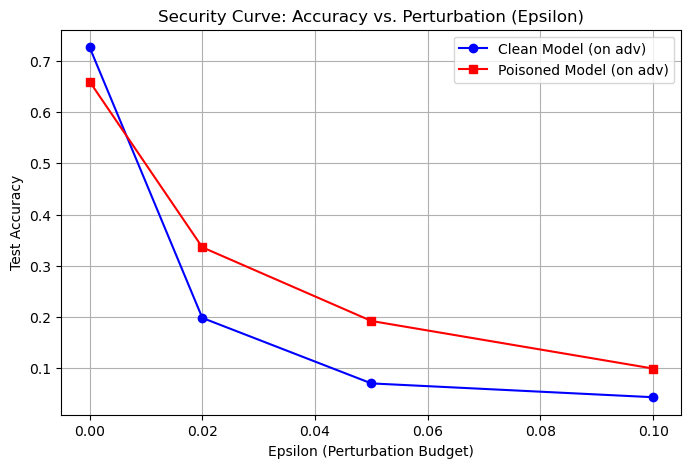

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(epsilons, curve_data["clean_m"], 'b-o', label='Clean Model (on adv)')
plt.plot(epsilons, curve_data["poison_m"], 'r-s', label='Poisoned Model (on adv)')
plt.title("Security Curve: Accuracy vs. Perturbation (Epsilon)")
plt.xlabel("Epsilon (Perturbation Budget)")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Analyze Failure Modes: Identify the 3 most vulnerable classes (compare clean vs adv)

In [31]:
eps_test = 0.05
x_adv_fail = run_fgsm(model_c, X_test_t, y_test_t, eps_test)

with torch.no_grad():
    logits_clean = model_c(X_test_t)
    preds_clean = logits_clean.argmax(dim=1).cpu().numpy()
    logits_adv = model_c(x_adv_fail)
    preds_adv = logits_adv.argmax(dim=1).cpu().numpy()

y_true_np = y_test_t.cpu().numpy()
num_classes = 43

per_class_clean_acc = np.zeros(num_classes)
per_class_adv_acc = np.zeros(num_classes)
for c in range(num_classes):
    idx = np.where(y_true_np == c)[0]
    if len(idx) == 0:
        per_class_clean_acc[c] = np.nan
        per_class_adv_acc[c] = np.nan
        continue
    per_class_clean_acc[c] = (preds_clean[idx] == y_true_np[idx]).mean()
    per_class_adv_acc[c] = (preds_adv[idx] == y_true_np[idx]).mean()

# compute drop = clean_acc - adv_acc
per_class_drop = per_class_clean_acc - per_class_adv_acc
valid_idx = np.where(~np.isnan(per_class_drop))[0]
top3 = valid_idx[np.argsort(per_class_drop[valid_idx])[-3:]][::-1]

print("\nTop 3 Vulnerable Classes under FGSM (eps=%.3f):" % eps_test)
for c in top3:
    print(f"Class {c}: clean_acc={per_class_clean_acc[c]:.3f}, adv_acc={per_class_adv_acc[c]:.3f}, drop={per_class_drop[c]:.3f}")


Top 3 Vulnerable Classes under FGSM (eps=0.050):
Class 42: clean_acc=1.000, adv_acc=0.000, drop=1.000
Class 34: clean_acc=1.000, adv_acc=0.000, drop=1.000
Class 16: clean_acc=1.000, adv_acc=0.000, drop=1.000


## **Part 2:  Defending Against Data Poisoning and Adversarial Attacks in Machine Learning**

### **Phase 1: Poisoning Defense Implementation**

In [9]:
# Converting CArray into nympy
X_train_np = X_train.tondarray()
y_train_np = y_train.tondarray()

X_test_np = X_test.tondarray()
y_test_np = y_test.tondarray()

In [10]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
preds = iso.fit_predict(X_train_np)

mask = preds == 1
X_train_clean = X_train_np[mask]
y_train_clean = y_train_np[mask]

print("Original:", X_train_np.shape)
print("After Cleaning:", X_train_clean.shape)

Original: (5000, 3072)
After Cleaning: (4500, 3072)


In [ ]:
# Robust Model (Dropout)
class GTSRB_CNN_Defense(nn.Module):
    def __init__(self):
        super(GTSRB_CNN_Defense, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),   # defense
            nn.Linear(128, 43)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Train clean model
model = GTSRB_CNN_Defense()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

clf = CClassifierPyTorch(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    epochs=10,  
    batch_size=32
)

clf.fit(CArray(X_train_clean), CArray(y_train_clean))

### **Phase 2: Adversarial Defense Strategies**

In [ ]:
# FGSM Attack
def fgsm_attack(model, x, y, epsilon=0.03):
    model.eval()
    
    x_tensor = torch.tensor(x.reshape(-1,3,32,32), requires_grad=True).float()
    y_tensor = torch.tensor(y).long()

    outputs = model(x_tensor)
    loss = nn.CrossEntropyLoss()(outputs, y_tensor)
    
    model.zero_grad()
    loss.backward()

    x_adv = x_tensor + epsilon * x_tensor.grad.sign()
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach().numpy().reshape(x.shape)

In [ ]:
# PGD Attack
def pgd_attack(model, x, y, epsilon=0.03, alpha=0.005, iters=5):
    x_adv = torch.tensor(x.reshape(-1,3,32,32)).float()
    y_tensor = torch.tensor(y).long()

    for i in range(iters):
        x_adv.requires_grad = True
        
        outputs = model(x_adv)
        loss = nn.CrossEntropyLoss()(outputs, y_tensor)

        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.sign()
        x_adv = torch.clamp(x_adv, 0, 1).detach()

    return x_adv.numpy().reshape(x.shape)

In [ ]:
# Generating PGD in batches 
batch_size = 256
X_pgd_list = []

for i in range(0, len(X_train_clean), batch_size):
    x_batch = X_train_clean[i:i+batch_size]
    y_batch = y_train_clean[i:i+batch_size]

    x_adv_batch = pgd_attack(model, x_batch, y_batch)
    X_pgd_list.append(x_adv_batch)

X_pgd = np.vstack(X_pgd_list)

In [ ]:
# Combine clean + adversarial to balanced it
X_combined = np.vstack((X_train_clean, X_pgd[:len(X_train_clean)]))
y_combined = np.hstack((y_train_clean, y_train_clean))

# Retrain with adversarial training
clf.fit(CArray(X_combined), CArray(y_combined))

GTSRB_CNN_Defense(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)

In [ ]:
# Randomized Smoothing
def randomized_smoothing(x, sigma=0.01):
    noise = np.random.normal(0, sigma, x.shape)
    return np.clip(x + noise, 0, 1)

### **Phase 3: Defense Evaluation**

In [ ]:
metric = CMetricAccuracy()

# Clean Accuracy
y_pred_clean = clf.predict(CArray(X_test_np))
acc_clean = metric.performance_score(CArray(y_test_np), y_pred_clean)
print(f"Clean Accuracy After Defense: {acc_clean:.4f}")

Clean Accuracy After Defense: 0.7800


In [ ]:
# Adversarial Accuracy
X_test_adv = fgsm_attack(model, X_test_np, y_test_np)

y_pred_adv = clf.predict(CArray(X_test_adv))
acc_adv = metric.performance_score(CArray(y_test_np), y_pred_adv)
print(f"Adversarial Accuracy After Defense: {acc_adv:.4f}")

Adversarial Accuracy After Defense: 0.2030


In [ ]:
# Smoothed Accuracy
X_test_smooth = randomized_smoothing(X_test_np)

y_pred_smooth = clf.predict(CArray(X_test_smooth))
acc_smooth = metric.performance_score(CArray(y_test_np), y_pred_smooth)
print(f"Smoothed Accuracy: {acc_smooth:.4f}")

Smoothed Accuracy: 0.7770


In [ ]:
# Attack Success Rate 
attack_success = 1 - acc_adv
print(f"Attack Success Rate: {attack_success:.4f}")

Attack Success Rate: 0.7970


In [ ]:
# Gradient Sensitivity 
def gradient_sensitivity(model, x, y):
    x_tensor = torch.tensor(x.reshape(-1,3,32,32), requires_grad=True).float()
    y_tensor = torch.tensor(y).long()

    outputs = model(x_tensor)
    loss = nn.CrossEntropyLoss()(outputs, y_tensor)

    loss.backward()
    return x_tensor.grad.abs().mean().item()

sens = gradient_sensitivity(model, X_test_np[:100], y_test_np[:100])
print("Gradient Sensitivity:", sens)

Gradient Sensitivity: 0.0005508645554073155


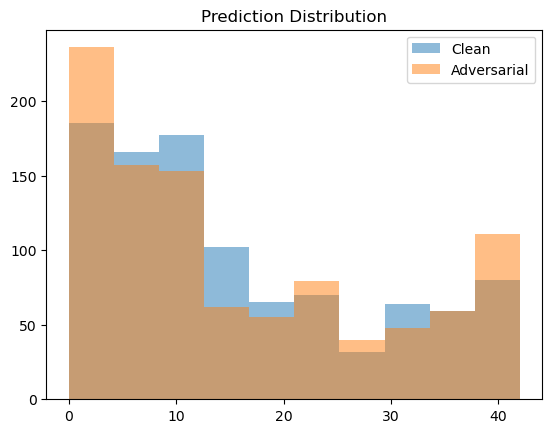

In [ ]:
# Prediction Distribution
import matplotlib.pyplot as plt

plt.hist(y_pred_clean.tondarray(), alpha=0.5, label="Clean")
plt.hist(y_pred_adv.tondarray(), alpha=0.5, label="Adversarial")
plt.legend()
plt.title("Prediction Distribution")
plt.show()

In [ ]:
print(f"Baseline Accuracy: {acc:.4f}")
print(f"Clean Accuracy After Defense: {acc_clean:.4f}")
print(f"Adversarial Accuracy After Defense: {acc_adv:.4f}")
print(f"Smoothed Accuracy: {acc_smooth:.4f}")
print(f"Attack Success Rate: {attack_success:.4f}")

Baseline Accuracy: 0.7610
Clean Accuracy After Defense: 0.7800
Adversarial Accuracy After Defense: 0.2030
Smoothed Accuracy: 0.7770
Attack Success Rate: 0.7970


### **Phase 4: Reporting & Advanced Exploration**